# Vegetation and Soil Types for Jedi Observation Simulators
This Notebook explores the following source of surface information for informing the CRTM lower boundary conditions. While GSI based applications rely on a low resolutiopn GFS file, here we explore more up-to-date data sources:

- MODIS land cover characterization from collection MCD12 given on the standard MODIS tiled sinosoidal grid.
- High resolution (read: raster, O(*1 km)) used for creating tile files for the GEOS land surface file. These files allow us to derive the fraction of sand, clay and silt from which we can derive soil texture indices.

# Python environment

In [1]:
import numpy  as np
import pandas as pd
import xarray as xr

import pyobs  as po

import matplotlib.pyplot as plt

from pyobs.ioda  import open_ioda # replacement for xr.open_datatree()

from pyobs.mcd12 import MCD12, Alias
from pyobs import sampler as sp


# Reference IODA file: ATMS
Assuming a discover environment at NCCS. Using the recently released xarray DataTree class for better handling the multitude of groups in the IODA files.

In [2]:
syn_hr = '20190812T120000Z'
beg_hr = '20190812T090000Z'  # beg of interval, 3 hours earlier
ioda_dn = '/discover/nobackup/projects/gmao/aist-nr/data/ioda/'+syn_hr+'/geos_atmosphere'
atms_fn = ioda_dn + '/atms_n20.'+beg_hr + '.nc4'

Using the recently released xarray DataTree class for better handling the multitude of groups in the IODA files. The *open_ioda()* wrapper brings space time coordinates to the root group.

In [3]:
ioda = open_ioda(atms_fn)
ioda

<xarray.DataTree>
Group: /
│   Dimensions:   (Channel: 22, Location: 10519)
│   Coordinates:
│     * Channel   (Channel) int32 88B 1 2 3 4 5 6 7 8 9 ... 15 16 17 18 19 20 21 22
│     * Location  (Location) int64 84kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
│       time      (Location) datetime64[ns] 84kB ...
│       lat       (Location) float32 42kB ...
│       lon       (Location) float32 42kB ...
│   Attributes:
│       _ioda_layout:          ObsGroup
│       _ioda_layout_version:  0
│       converter:             gsi_ncdiag.py
├── Group: /GsiBc
│       Dimensions:                (Location: 10519, Channel: 22)
│       Data variables:
│           brightnessTemperature  (Location, Channel) float32 926kB ...
├── Group: /GsiEffectiveQC
│       Dimensions:                (Location: 10519, Channel: 22)
│       Data variables:
│           brightnessTemperature  (Location, Channel) float64 2MB ...
├── Group: /GsiFinalObsError
│       Dimensions:                (Location: 10519, Channel: 22)
│       Data variables:
│           brightnessTemperature  (Location, Channel) float32 926kB ...
├── Group: /GsiHofX
│       Dimensions:                (Location: 10519, Channel: 22)
│       Data variables:
│           brightnessTemperature  (Location, Channel) float32 926kB ...
├── Group: /GsiHofXBc
│       Dimensions:                (Location: 10519, Channel: 22)
│       Data variables:
│           brightnessTemperature  (Location, Channel) float32 926kB ...
├── Group: /GsiHofXClr
│       Dimensions:                (Location: 10519, Channel: 22)
│       Data variables:
│           brightnessTemperature  (Location, Channel) float32 926kB ...
├── Group: /GsiInputObsError
│       Dimensions:                (Location: 10519, Channel: 22)
│       Data variables:
│           brightnessTemperature  (Location, Channel) float32 926kB ...
├── Group: /MetaData
│       Dimensions:                                      (Location: 10519, Channel: 22)
│       Data variables: (12/18)
│           cloudWaterRetrievedFromObservation           (Location) float32 42kB ...
│           cloudWaterRetrievedFromSimulatedObservation  (Location) float32 42kB ...
│           cloud_frac                                   (Location) float32 42kB ...
│           dateTime                                     (Location) datetime64[ns] 84kB ...
│           heightOfSurface                              (Location) float32 42kB ...
│           latitude                                     (Location) float32 42kB ...
│           ...                                           ...
│           sensorPolarizationDirection                  (Channel) float32 88B ...
│           sensorScanPosition                           (Location) float64 84kB ...
│           sensorViewAngle                              (Location) float32 42kB ...
│           sensorZenithAngle                            (Location) float32 42kB ...
│           solarAzimuthAngle                            (Location) float32 42kB ...
│           solarZenithAngle                             (Location) float32 42kB ...
├── Group: /ObsError
│       Dimensions:                (Location: 10519, Channel: 22)
│       Data variables:
│           brightnessTemperature  (Location, Channel) float32 926kB ...
├── Group: /ObsValue
│       Dimensions:                (Location: 10519, Channel: 22)
│       Data variables:
│           brightnessTemperature  (Location, Channel) float32 926kB ...
└── Group: /PreQC
        Dimensions:                (Location: 10519, Channel: 22)
        Data variables:
            brightnessTemperature  (Location, Channel) float64 2MB ...

In [4]:
def plotSwathLatLon(lon, lat, title, colors=None, size=2, cmap='plasma'):
    """
    Plot orbits for a couple of days in 2019.
    """ 
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    fig = plt.figure(figsize=[15, 15])
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.stock_img()
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.COASTLINE)
    if colors is None:
        ax.plot(lon,lat, '.')
    else:
        scat = ax.scatter(lon,lat,s=size,c=colors,cmap=cmap)
        fig.colorbar(scat,shrink=0.4)
    ax.title.set_text(title)

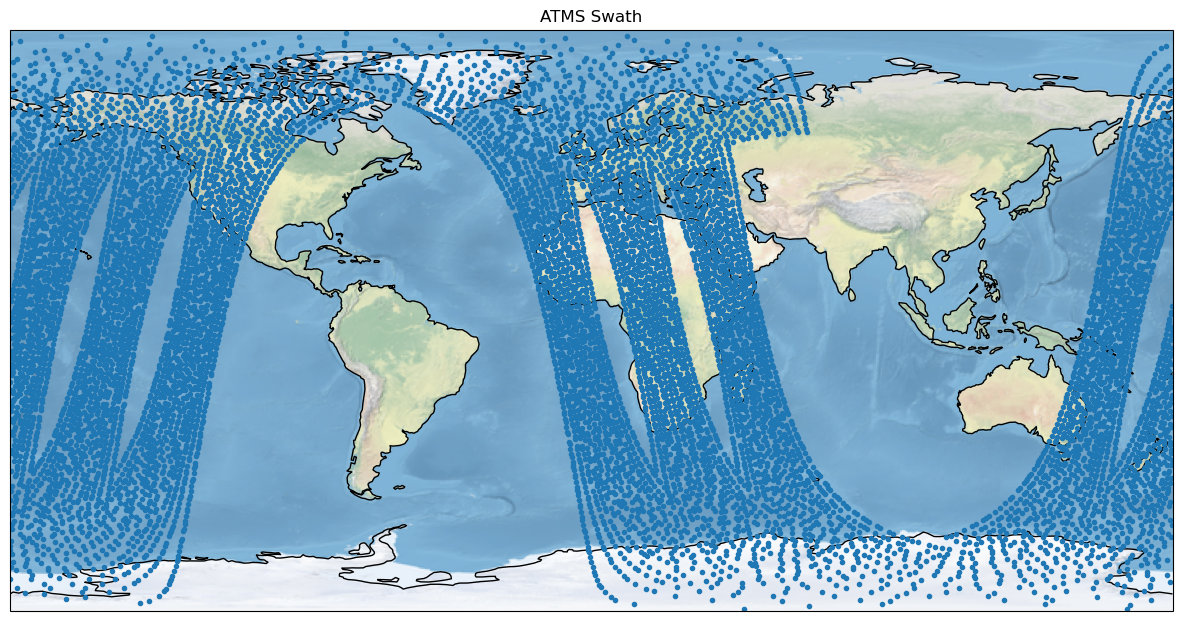

In [5]:
lon, lat = ioda.lon.values, ioda.lat.values
I = lon>180
lon[I] = lon[I] - 360.
plotSwathLatLon(lon,lat, 'ATMS Swath')

## Land Cover
Get IGBP land cover from MODIS product MCD12Q1.

In [6]:
mcd12q1_dn = '/css/modis/Collection6.1/L3/MCD12Q1-Landcover/2019/001'
land = MCD12(mcd12q1_dn,lon,lat,Alias=Alias)

In [7]:
V = land.interp_many(['LC_IGBP', 'LW', 'QC'],method='nearest')
V

<xarray.Dataset> Size: 337kB
Dimensions:  (nobs: 10519)
Coordinates:
    lon      (nobs) float32 42kB 13.27 7.383 5.964 ... -32.81 -15.32 -8.198
    lat      (nobs) float32 42kB -87.97 -86.45 -85.68 ... 86.59 86.96 87.47
Dimensions without coordinates: nobs
Data variables:
    LC_IGBP  (nobs) float64 84kB 15.0 15.0 15.0 15.0 ... 17.0 17.0 17.0 17.0
    LW       (nobs) float64 84kB 2.0 2.0 2.0 2.0 2.0 2.0 ... 1.0 1.0 1.0 1.0 1.0
    QC       (nobs) float64 84kB 6.0 6.0 6.0 6.0 6.0 6.0 ... 3.0 3.0 3.0 3.0 3.0

## Soil Texture


In [8]:
soil_dn = '/discover/nobackup/projects/gmao/aist-nr/data/soil_properties/global'
soil_fn = soil_dn + '/geos.soil_texture.x43200_y21601.nc4'  # 30 arcsec resolution
soil = xr.open_dataset(soil_fn,engine='netcdf4',chunks={'lat': 1200, 'lon': 1200})
soil

<xarray.Dataset> Size: 30GB
Dimensions:     (lon: 43200, lat: 21601)
Coordinates:
  * lon         (lon) float64 346kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * lat         (lat) float64 173kB -90.0 -89.99 -89.98 ... 89.98 89.99 90.0
Data variables:
    Clay0_30    (lat, lon) float32 4GB dask.array<chunksize=(1200, 1200), meta=np.ndarray>
    Clay30_100  (lat, lon) float32 4GB dask.array<chunksize=(1200, 1200), meta=np.ndarray>
    Gravel      (lat, lon) float32 4GB dask.array<chunksize=(1200, 1200), meta=np.ndarray>
    Mask        (lat, lon) float32 4GB dask.array<chunksize=(1200, 1200), meta=np.ndarray>
    OC0_30      (lat, lon) float32 4GB dask.array<chunksize=(1200, 1200), meta=np.ndarray>
    OC30_100    (lat, lon) float32 4GB dask.array<chunksize=(1200, 1200), meta=np.ndarray>
    Sand0_30    (lat, lon) float32 4GB dask.array<chunksize=(1200, 1200), meta=np.ndarray>
    Sand30_100  (lat, lon) float32 4GB dask.array<chunksize=(1200, 1200), meta=np.ndarray>
Attributes:
    title:        GEOS LSM Soil Texture
    conventions:  CF
    institution:  Global Modeling and Assimilation Office, NASA/GSFC
    source:       Tile files written by Sarith Mahanama for the GEOS LSM
    history:      A. da Silva created this CF compliant global file
    contact:      arlindo.m.dasilva@nasa.gov

## Sample Soil variables

In [9]:
stations = list(range(lon.size))
s = sp.STATION(stations, lon, lat, soil_fn, verbose=True)
S = s.sample(Variables=['Clay0_30','Sand0_30', 'OC0_30', 'Gravel', 'Mask'],
             method='nearest').rename(station='nobs')
S

[ ] sampling  Clay0_30
[ ] sampling  Sand0_30
[ ] sampling  OC0_30
[ ] sampling  Gravel
[ ] sampling  Mask


<xarray.Dataset> Size: 463kB
Dimensions:   (nobs: 10519)
Coordinates:
    lon       (nobs) float64 84kB 13.28 7.383 5.967 37.29 ... -32.81 -15.32 -8.2
    lat       (nobs) float64 84kB -87.97 -86.45 -85.68 ... 86.59 86.96 87.47
  * nobs      (nobs) int64 84kB 0 1 2 3 4 5 ... 10514 10515 10516 10517 10518
Data variables:
    Clay0_30  (nobs) float32 42kB dask.array<chunksize=(10519,), meta=np.ndarray>
    Sand0_30  (nobs) float32 42kB dask.array<chunksize=(10519,), meta=np.ndarray>
    OC0_30    (nobs) float32 42kB dask.array<chunksize=(10519,), meta=np.ndarray>
    Gravel    (nobs) float32 42kB dask.array<chunksize=(10519,), meta=np.ndarray>
    Mask      (nobs) float32 42kB dask.array<chunksize=(10519,), meta=np.ndarray>

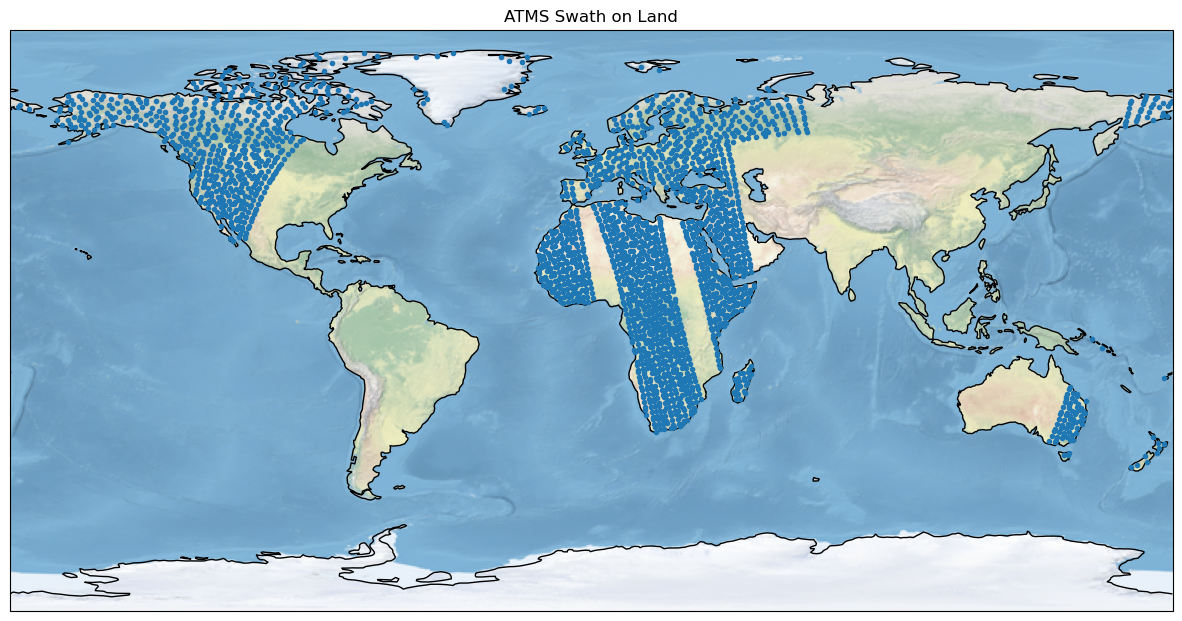

In [10]:
m = S.Mask.values
J = (m==20)|(m==19)|(m==0)
plotSwathLatLon(lon[~J],lat[~J], 'ATMS Swath on Land')

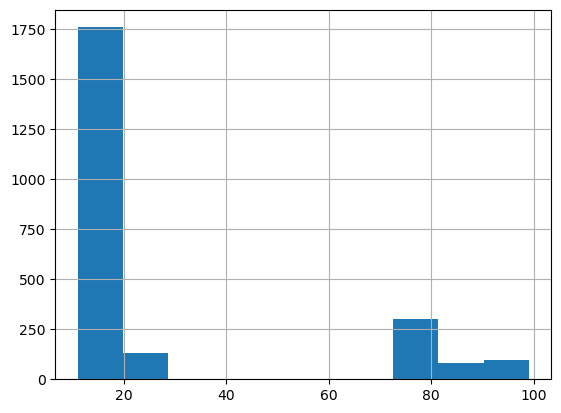

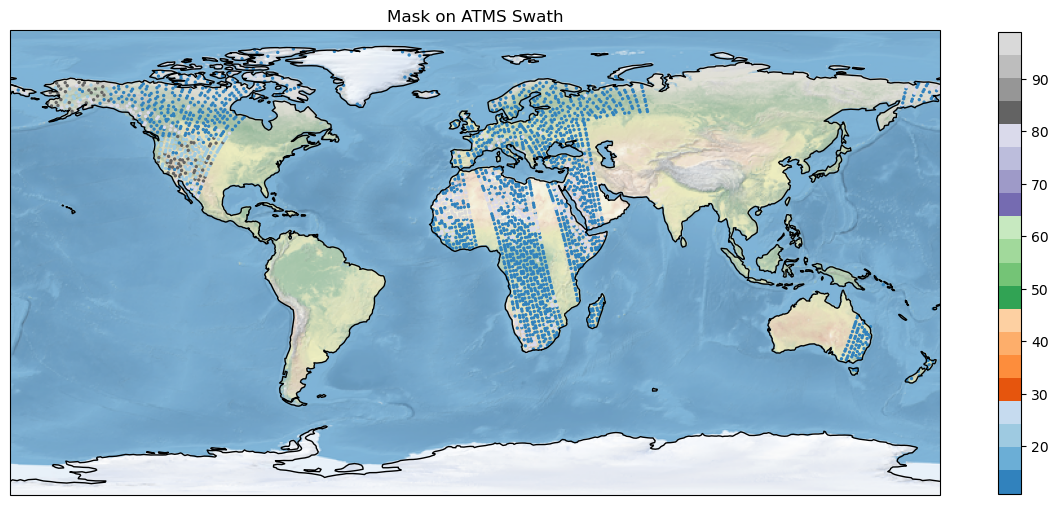

In [11]:
plt.hist(S.Mask.values[~J])
plt.grid()
plotSwathLatLon(lon[~J],lat[~J], 'Mask on ATMS Swath',
                colors=S.Mask.values[~J],cmap='tab20c')

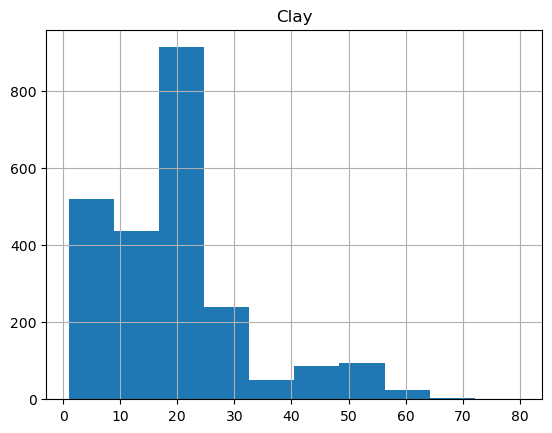

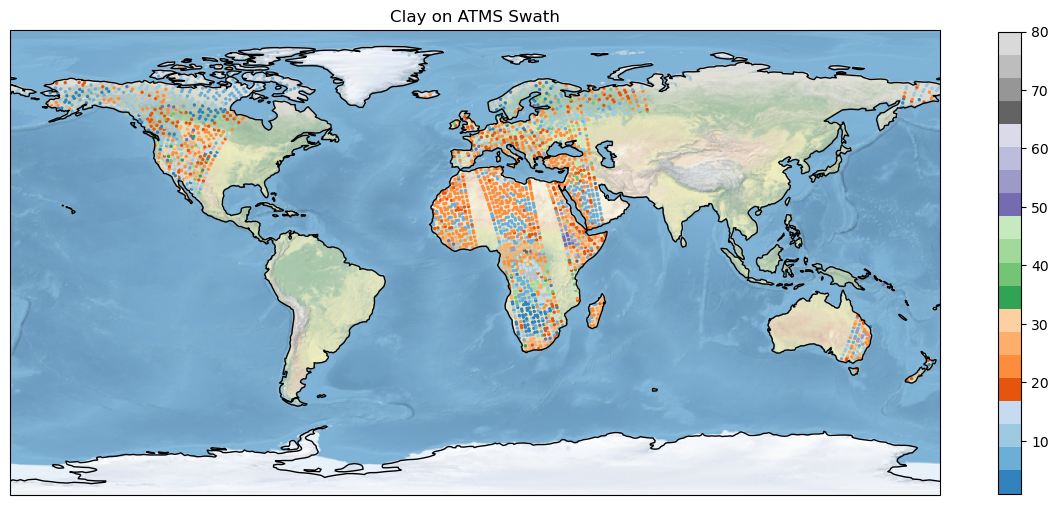

In [12]:
plt.hist(S.Clay0_30[~J])
plt.title('Clay')
plt.grid()
plotSwathLatLon(lon[~J],lat[~J], 'Clay on ATMS Swath',
                colors=S.Clay0_30.values[~J],cmap='tab20c')

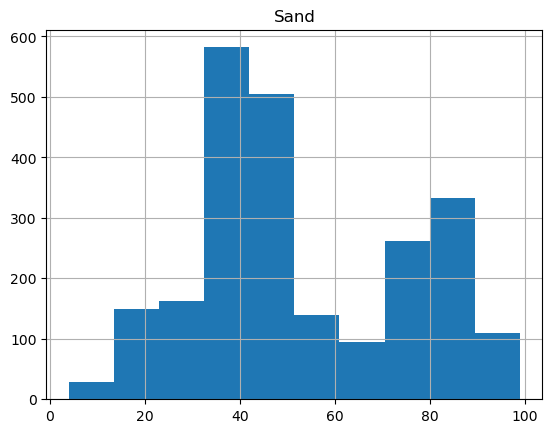

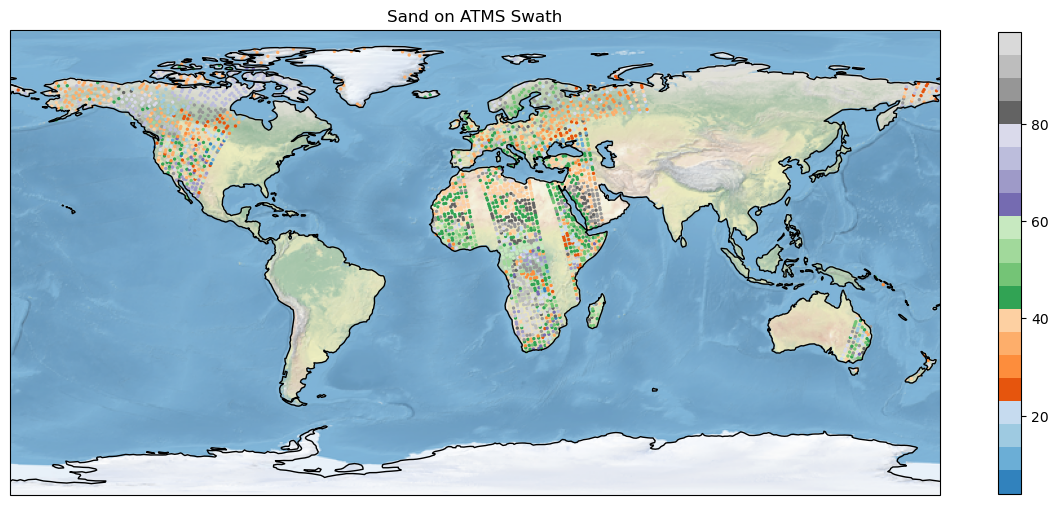

In [13]:
plt.hist(S.Sand0_30[~J])
plt.title('Sand')
plt.grid()
plotSwathLatLon(lon[~J],lat[~J], 'Sand on ATMS Swath',
                colors=S.Sand0_30.values[~J],cmap='tab20c')

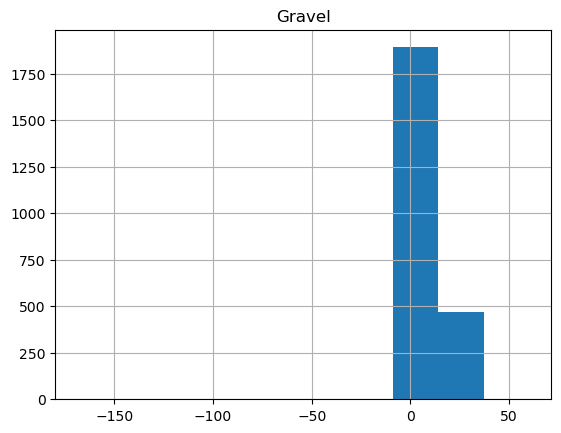

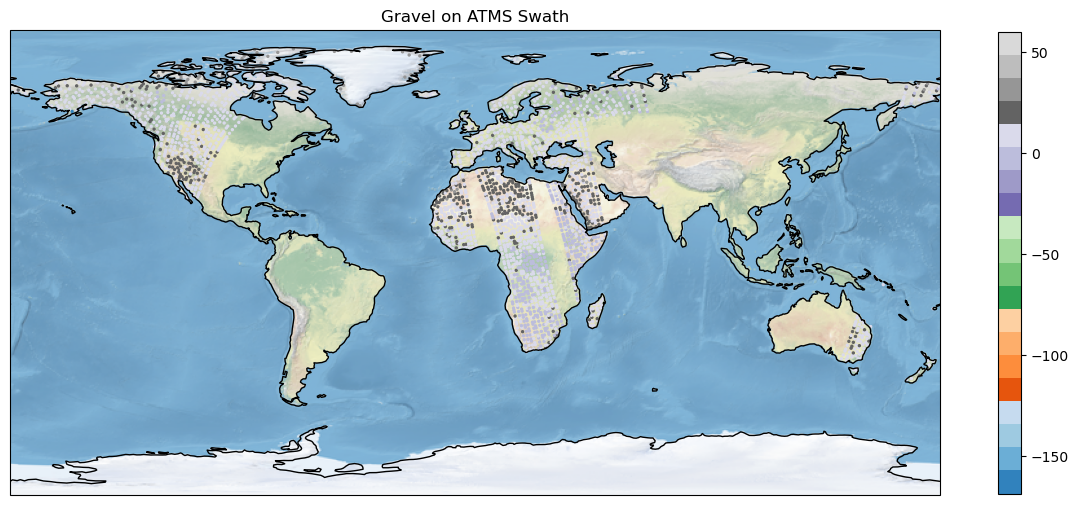

In [14]:
plt.hist(S.Gravel[~J])
plt.title('Gravel')
plt.grid()
plotSwathLatLon(lon[~J],lat[~J], 'Gravel on ATMS Swath',
                colors=S.Gravel.values[~J],cmap='tab20c')

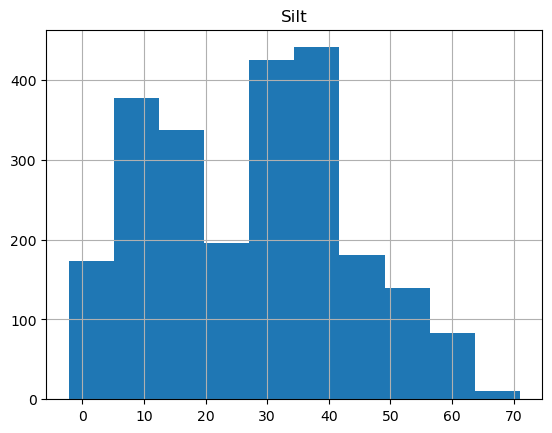

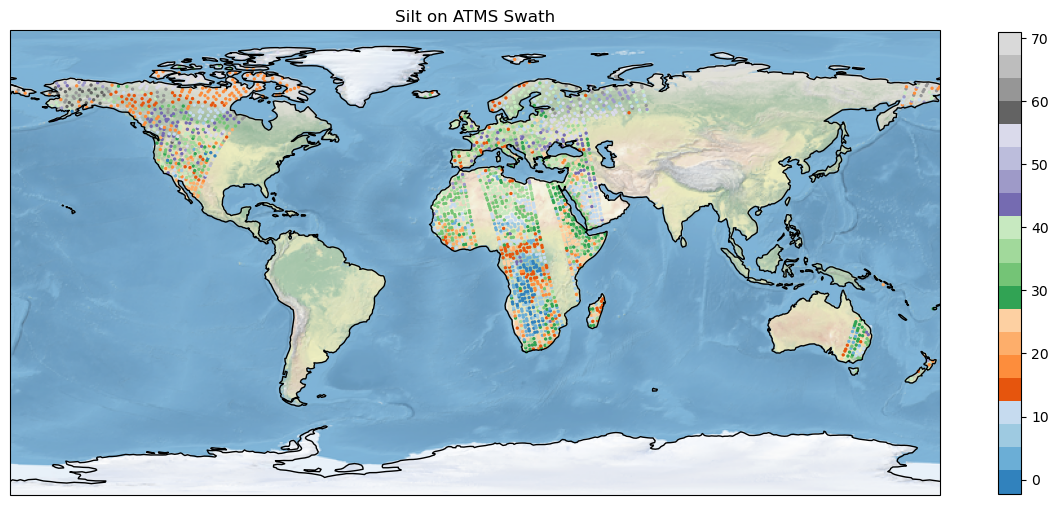

In [15]:
Silt0_30 = 100 - (S.Clay0_30 + S.Sand0_30)
plt.hist(Silt0_30[~J])
plt.title('Silt')
plt.grid()
plotSwathLatLon(lon[~J],lat[~J], 'Silt on ATMS Swath',
                colors=Silt0_30.values[~J],cmap='tab20c')